# Full-Trace Analysis

Each observation is one complete 20-prompt continuous trace (no inter-trial reset).



In [50]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

# ── Configuration ──────────────────────────────────────────────────────────
BASE_DIR  = Path.home() / 'Desktop' / 'mccviahat'
DATA_DIR  = BASE_DIR / 'data' / 'fulltrace'

FEATURES = [
    'core_power.throttle__mean_rate',
    'core_power.throttle__variance',
    'core_power.throttle__spectral_entropy',
    'core_power.throttle__slope',
    'core_power.throttle__lz_complexity',
]

SHORT = {f: f.split('__')[-1] for f in FEATURES}

SEED = 42
N_PERMUTATIONS = 10_000
N_BOOTSTRAP    = 5_000

print('Configuration OK')

Configuration OK


## §1 — Load data

In [51]:
# Load all *_whole.csv files from the fulltrace directory
whole_csvs = sorted(DATA_DIR.glob('*_whole.csv'))


dfs = [pd.read_csv(p) for p in whole_csvs]
df = pd.concat(dfs, ignore_index=True)

if 'condition' not in df.columns and 'label' in df.columns:
    df['condition'] = df['label']

# Deduplicate on run_label — keep first occurrence
dropped = df[df.duplicated(subset='run_label', keep='first')]['run_label'].tolist()
df = df.drop_duplicates(subset='run_label', keep='first').reset_index(drop=True)
if dropped:
    print(f'\nDropped {len(dropped)} duplicate run_labels: {dropped}')

n_e = (df.condition == 'emotional').sum()
n_n = (df.condition == 'neutral').sum()


available = []
for f in FEATURES:
    ok = f in df.columns
    print(f'  {"✓" if ok else "✗"} {SHORT[f]}')
    if ok:
        available.append(f)
FEATURES = available

print('\nData loaded successfully')

  ✓ mean_rate
  ✓ variance
  ✓ spectral_entropy
  ✓ slope
  ✓ lz_complexity

Data loaded successfully


## §2 — Per-feature univariate tests

For each feature independently:
- Descriptive statistics
- Two-sample t-test (tests difference in means, assumes normality)
- Mann-Whitney U (tests distributional shift, no assumptions)

In [52]:
e_mask = df['condition'] == 'emotional'
n_mask = df['condition'] == 'neutral'

results = []

for feat in FEATURES:
    e_vals = df.loc[e_mask, feat].dropna().values
    n_vals = df.loc[n_mask, feat].dropna().values
    name = SHORT[feat]

    e_mean, e_std = np.mean(e_vals), np.std(e_vals, ddof=1)
    n_mean, n_std = np.mean(n_vals), np.std(n_vals, ddof=1)
    direction = '↑E' if e_mean > n_mean else '↑N'

    # Cohen's d
    pooled_std = np.sqrt((e_std**2 + n_std**2) / 2)
    cohens_d = abs(e_mean - n_mean) / pooled_std if pooled_std > 0 else np.nan

    # t-test
    t_stat, t_p = ttest_ind(e_vals, n_vals, equal_var=False)

    # MWU
    u_stat, mwu_p = mannwhitneyu(e_vals, n_vals, alternative='two-sided')

    results.append({
        'feature': name, 'direction': direction,
        'e_mean': e_mean, 'e_std': e_std,
        'n_mean': n_mean, 'n_std': n_std,
        'cohens_d': cohens_d,
        't_stat': t_stat, 't_p': t_p,
        'U': u_stat, 'mwu_p': mwu_p,
    })

res_df = pd.DataFrame(results)

# Bonferroni correction
n_tests = len(results)
res_df['t_p_corr'] = (res_df['t_p'] * n_tests).clip(upper=1.0)
res_df['mwu_p_corr'] = (res_df['mwu_p'] * n_tests).clip(upper=1.0)

print(f'Per-feature tests (n_E={n_e}, n_N={n_n}, Bonferroni k={n_tests})')
print('=' * 110)
print(f'{"Feature":>20s}  {"Dir":>3s}  {"E mean":>12s}  {"N mean":>12s}  '
      f'{"Cohen d":>8s}  {"t":>8s}  {"t p_corr":>10s}  {"U":>8s}  {"MWU p_corr":>10s}')
print('-' * 110)
for _, r in res_df.iterrows():
    sig_t = '*' if r['t_p_corr'] < 0.05 else ' '
    sig_m = '*' if r['mwu_p_corr'] < 0.05 else ' '
    print(f'{r["feature"]:>20s}  {r["direction"]:>3s}  '
          f'{r["e_mean"]:12.4f}  {r["n_mean"]:12.4f}  '
          f'{r["cohens_d"]:8.4f}  {r["t_stat"]:8.3f}  '
          f'{r["t_p_corr"]:10.4f}{sig_t} '
          f'{r["U"]:8.1f}  '
          f'{r["mwu_p_corr"]:10.4f}{sig_m}')
print()
print('* = significant after Bonferroni correction (p_corr < 0.05)')

Per-feature tests (n_E=20, n_N=20, Bonferroni k=5)
             Feature  Dir        E mean        N mean   Cohen d         t    t p_corr         U  MWU p_corr
--------------------------------------------------------------------------------------------------------------
           mean_rate   ↑E    12256.9628    11695.9521    0.8103     2.562      0.0726     308.0      0.0182*
            variance   ↑E  37090275330696.4219  36166456557074.1094    0.1083     0.343      1.0000     210.0      1.0000 
    spectral_entropy   ↑E        0.9187        0.9055    0.6169     1.951      0.2947     264.0      0.4293 
               slope   ↑N       11.7487       12.2269    0.0815    -0.258      1.0000     216.0      1.0000 
       lz_complexity   ↑E        7.0631        6.9897    0.3574     1.130      1.0000     246.0      1.0000 

* = significant after Bonferroni correction (p_corr < 0.05)


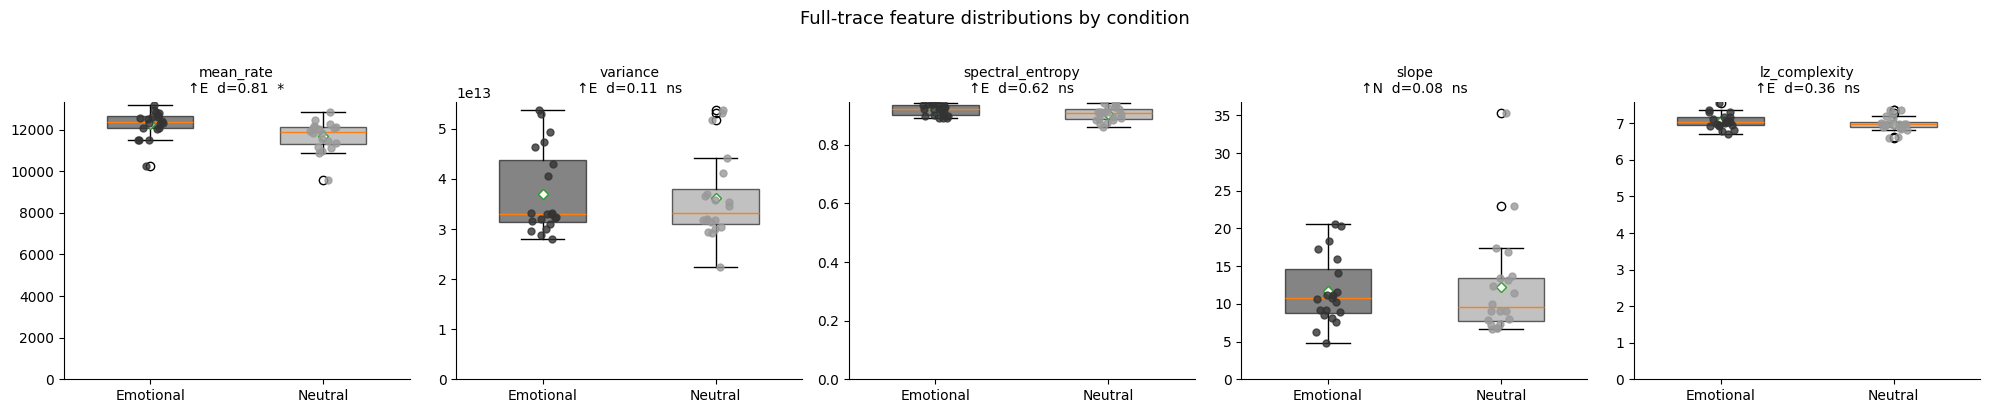

In [53]:
n_feat = len(FEATURES)
fig, axes = plt.subplots(1, n_feat, figsize=(4 * n_feat, 4), sharey=False)
if n_feat == 1:
    axes = [axes]

for ax, feat in zip(axes, FEATURES):
    e_vals = df.loc[e_mask, feat].dropna().values
    n_vals = df.loc[n_mask, feat].dropna().values
    name = SHORT[feat]

    positions = [0, 1]
    bp = ax.boxplot([e_vals, n_vals], positions=positions, widths=0.5,
                    patch_artist=True, showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='white', markersize=5))
    bp['boxes'][0].set_facecolor('#333333')
    bp['boxes'][1].set_facecolor('#999999')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_alpha(0.6)

    jitter = 0.08
    rng_j = np.random.default_rng(42)
    ax.scatter(np.zeros(len(e_vals)) + rng_j.uniform(-jitter, jitter, len(e_vals)),
               e_vals, color='#333333', s=25, zorder=5, alpha=0.8)
    ax.scatter(np.ones(len(n_vals)) + rng_j.uniform(-jitter, jitter, len(n_vals)),
               n_vals, color='#999999', s=25, zorder=5, alpha=0.8)

    r = res_df[res_df.feature == name].iloc[0]
    sig = '***' if r['mwu_p_corr'] < 0.001 else '**' if r['mwu_p_corr'] < 0.01 else '*' if r['mwu_p_corr'] < 0.05 else 'ns'
    ax.set_title(f'{name}\n{r["direction"]}  d={r["cohens_d"]:.2f}  {sig}', fontsize=10)
    ax.set_xticks(positions)
    ax.set_xticklabels(['Emotional', 'Neutral'])
    ax.spines[['top', 'right']].set_visible(False)

    ax.set_ylim(bottom=0)

fig.suptitle('Full-trace feature distributions by condition', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## §2b — Per-feature intra/inter group distances

For each feature indipendently:
- Mean within-emotional distance (intra-E)
- Mean within-neutral distance (intra-N)
- Mean cross-condition distance (inter)
- Ratio inter/intra and t-test on the distances

In [54]:
print('Per-feature intra/inter group distances')
print('=' * 100)
print(f'{"Feature":>20s}  {"Intra-E":>10s}  {"Intra-N":>10s}  '
      f'{"Intra(avg)":>10s}  {"Inter":>10s}  {"Inter/Intra":>12s}  {"Dir":>3s}')
print('-' * 100)

dist_1d_results = []

for feat in FEATURES:
    name = SHORT[feat]
    e_vals = df.loc[e_mask, feat].dropna().values
    n_vals = df.loc[n_mask, feat].dropna().values

    # Within-emotional: all unique pairs |xi - xj|
    intra_e = []
    for i in range(len(e_vals)):
        for j in range(i + 1, len(e_vals)):
            intra_e.append(abs(e_vals[i] - e_vals[j]))
    intra_e = np.array(intra_e) if intra_e else np.array([np.nan])

    # Within-neutral: all unique pairs
    intra_n = []
    for i in range(len(n_vals)):
        for j in range(i + 1, len(n_vals)):
            intra_n.append(abs(n_vals[i] - n_vals[j]))
    intra_n = np.array(intra_n) if intra_n else np.array([np.nan])

    # Cross-condition: every e vs every n
    inter = []
    for ev in e_vals:
        for nv in n_vals:
            inter.append(abs(ev - nv))
    inter = np.array(inter) if inter else np.array([np.nan])

    mean_ie = np.mean(intra_e)
    mean_in = np.mean(intra_n)
    mean_intra = np.mean(np.concatenate([intra_e, intra_n]))
    mean_inter = np.mean(inter)
    ratio = mean_inter / mean_intra if mean_intra > 0 else np.nan

    r = res_df[res_df.feature == name].iloc[0]
    direction = r['direction']

    dist_1d_results.append({
        'feature': name, 'direction': direction,
        'intra_e': mean_ie, 'intra_n': mean_in,
        'intra_avg': mean_intra, 'inter': mean_inter,
        'ratio': ratio,
    })

    print(f'{name:>20s}  {mean_ie:10.4f}  {mean_in:10.4f}  '
          f'{mean_intra:10.4f}  {mean_inter:10.4f}  {ratio:12.4f}  {direction:>3s}')

dist_1d_df = pd.DataFrame(dist_1d_results)

print()
print('Interpretation:')
print('  Inter/Intra > 1.0 → cross-condition pairs are farther apart than within-condition pairs')
print('  Inter/Intra ≈ 1.0 → conditions overlap completely')

Per-feature intra/inter group distances
             Feature     Intra-E     Intra-N  Intra(avg)       Inter   Inter/Intra  Dir
----------------------------------------------------------------------------------------------------
           mean_rate    703.9544    780.7010    742.3277    867.0572        1.1680   ↑E
            variance  9270380765490.0039  9235179764093.4863  9252780264791.7441  8958594846963.4316        0.9682   ↑E
    spectral_entropy      0.0217      0.0281      0.0249      0.0263        1.0565   ↑E
               slope      5.1495      6.7570      5.9533      5.8010        0.9744   ↑N
       lz_complexity      0.2356      0.2276      0.2316      0.2297        0.9921   ↑E

Interpretation:
  Inter/Intra > 1.0 → cross-condition pairs are farther apart than within-condition pairs
  Inter/Intra ≈ 1.0 → conditions overlap completely


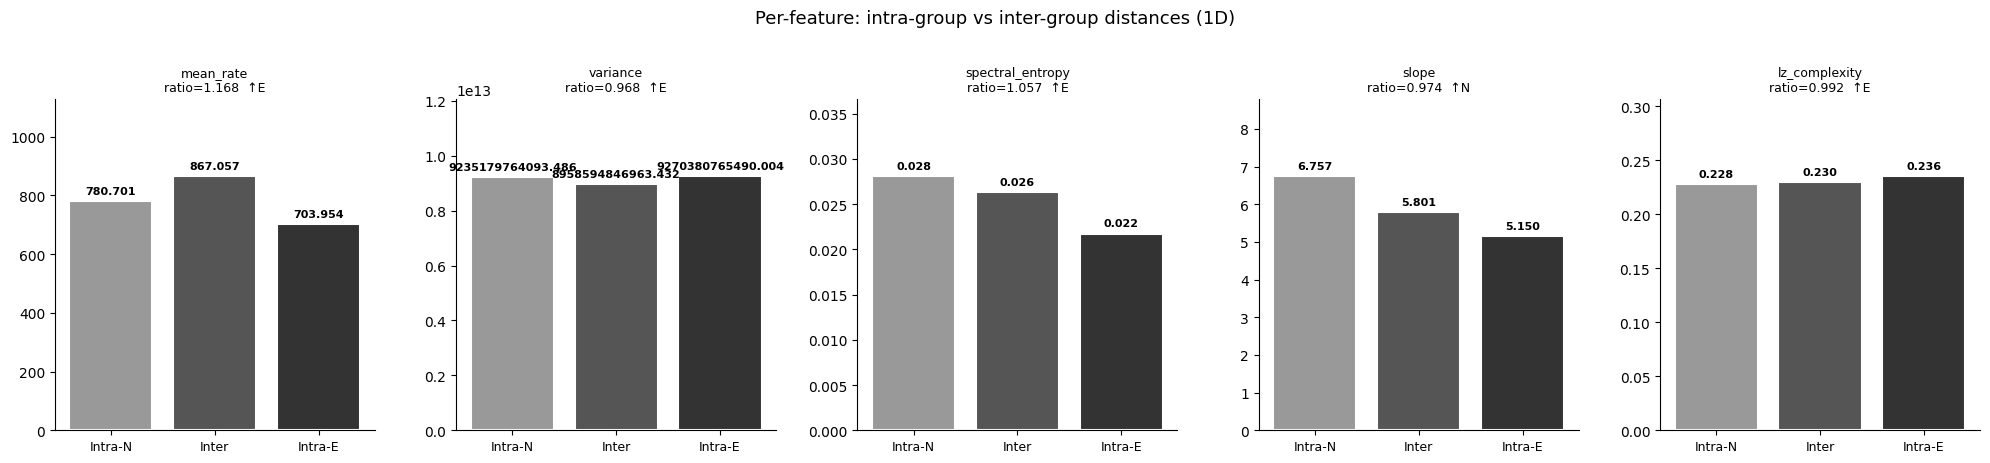

In [55]:
# Visualise per-feature intra vs inter distances
n_feat = len(FEATURES)
fig, axes = plt.subplots(1, n_feat, figsize=(4 * n_feat, 4.5), sharey=False)
if n_feat == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, dist_1d_df.iterrows()):
    vals = [row['intra_n'], row['inter'], row['intra_e']]
    labels = ['Intra-N', 'Inter', 'Intra-E']
    colors = ['#999999', '#555555', '#333333']
    bars = ax.bar(range(3), vals, color=colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xticks(range(3))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(f'{row["feature"]}\nratio={row["ratio"]:.3f}  {row["direction"]}', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, max(vals) * 1.3)

fig.suptitle('Per-feature: intra-group vs inter-group distances (1D)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## §4 — Summary

In [56]:
print('=' * 70)
print('FULL-TRACE ANALYSIS SUMMARY')
print('=' * 70)
print(f'Traces         : {n_e} emotional, {n_n} neutral')
print(f'Features       : {len(FEATURES)}')
print()

print('PER-FEATURE RESULTS (Bonferroni-corrected):')
print(f'{"Feature":>20s}  {"Dir":>3s}  {"Cohen d":>8s}  {"t p_corr":>10s}  {"MWU p_corr":>10s}  {"Sig":>5s}')
print('-' * 65)
for _, r in res_df.iterrows():
    sig = 'YES' if (r['t_p_corr'] < 0.05 or r['mwu_p_corr'] < 0.05) else 'no'
    print(f'{r["feature"]:>20s}  {r["direction"]:>3s}  {r["cohens_d"]:8.4f}  '
          f'{r["t_p_corr"]:10.4f}  {r["mwu_p_corr"]:10.4f}  {sig:>5s}')


print(f'\nPER-FEATURE DISTANCE RATIOS (inter/intra):')
print(f'{"Feature":>20s}  {"Inter/Intra":>12s}  {"Dir":>3s}')
print('-' * 40)
for _, r in dist_1d_df.iterrows():
    print(f'{r["feature"]:>20s}  {r["ratio"]:12.4f}  {r["direction"]:>3s}')




FULL-TRACE ANALYSIS SUMMARY
Traces         : 20 emotional, 20 neutral
Features       : 5

PER-FEATURE RESULTS (Bonferroni-corrected):
             Feature  Dir   Cohen d    t p_corr  MWU p_corr    Sig
-----------------------------------------------------------------
           mean_rate   ↑E    0.8103      0.0726      0.0182    YES
            variance   ↑E    0.1083      1.0000      1.0000     no
    spectral_entropy   ↑E    0.6169      0.2947      0.4293     no
               slope   ↑N    0.0815      1.0000      1.0000     no
       lz_complexity   ↑E    0.3574      1.0000      1.0000     no

PER-FEATURE DISTANCE RATIOS (inter/intra):
             Feature   Inter/Intra  Dir
----------------------------------------
           mean_rate        1.1680   ↑E
            variance        0.9682   ↑E
    spectral_entropy        1.0565   ↑E
               slope        0.9744   ↑N
       lz_complexity        0.9921   ↑E


## TTR analysis

In [57]:
import json
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu

def ttr(text):
    tokens = text.lower().split()
    return len(set(tokens)) / len(tokens) if tokens else 0

# Load prompts
with open('../../prompts/20base/independentE.json') as f:
    emotional = json.load(f)
with open('../../prompts/20base/independentN.json') as f:
    neutral = json.load(f)

e_ttr = [ttr(p['instructions']) for p in emotional]
n_ttr = [ttr(p['instructions']) for p in neutral]

print('Type-to-Token Ratio (word-level)')
print('=' * 50)
print(f'Emotional  n={len(e_ttr):3d}  mean={np.mean(e_ttr):.4f}  std={np.std(e_ttr):.4f}')
print(f'Neutral    n={len(n_ttr):3d}  mean={np.mean(n_ttr):.4f}  std={np.std(n_ttr):.4f}')

t, p_t = ttest_ind(e_ttr, n_ttr)
u, p_u = mannwhitneyu(e_ttr, n_ttr, alternative='two-sided')
print(f'\nt-test:  t={t:.4f}  p={p_t:.4f}')
print(f'MWU:     U={u:.1f}  p={p_u:.4f}')
print(f'\nSignificant difference: {p_t < 0.05}')

Type-to-Token Ratio (word-level)
Emotional  n= 20  mean=0.6723  std=0.0398
Neutral    n= 20  mean=0.6044  std=0.0367

t-test:  t=5.4698  p=0.0000
MWU:     U=358.0  p=0.0000

Significant difference: True
